# Homework 2.1 — Group Fixed Effects Regression

**Question.** Run a regression that estimates the fixed effect of each group. Assume there is a
*single* linear coefficient shared by all the data, plus a fixed effect for each group.
Data: `homework_2.1.csv`. `G1`, `G2`, `G3` are the outcomes, `time` is the treatment.

**Model**

$$y_{g,t} \;=\; \alpha_g \;+\; \beta\, t \;+\; \varepsilon_{g,t}, \qquad g \in \{G1, G2, G3\}$$

- $\beta$ — one common slope on `time`, estimated from **all** the data pooled together.
- $\alpha_{G1}, \alpha_{G2}, \alpha_{G3}$ — the group fixed effects (group-specific intercepts).

To fit this, the wide data (one column per group) is reshaped into **long** form — one row per
(group, time) observation — and estimated by OLS with a full set of group dummies and **no
overall intercept**, so each dummy coefficient *is* that group's fixed effect $\alpha_g$.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not installed - the manual NumPy section below gives the same answers.")

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
CSV_PATH = "homework_2.1.csv"   # <-- change if the file lives somewhere else

statsmodels not installed - the manual NumPy section below gives the same answers.


## 2. Load and inspect the data

In [2]:
df = pd.read_csv(CSV_PATH)

print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes, sep="")
print("\nmissing values per column:\n", df.isna().sum(), sep="")
df.head()

shape: (100, 4)

dtypes:
time      int64
G1      float64
G2      float64
G3      float64
dtype: object

missing values per column:
time    0
G1      0
G2      0
G3      0
dtype: int64


,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066


In [3]:
df.describe()

,time,G1,G2,G3
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.524904,1.036006,0.715384
std,29.011492,0.561614,0.552593,0.581227
min,0.000000,-1.076495,-0.163880,-0.508478
25%,24.750000,0.186046,0.621088,0.298386
50%,49.500000,0.464842,1.006778,0.643041
75%,74.250000,0.947191,1.427074,1.125461
max,99.000000,1.862935,2.561618,2.321958


## 3. Identify the treatment column and the outcome columns

`time` is stored as **whole numbers**; the three outcomes are **rational / decimal** values.
That is used here as an automatic check, so the script still picks the right columns even if
the headers are missing, misspelled, or in a different order.

In [4]:
def is_whole_number_column(s: pd.Series) -> bool:
    # True if every non-missing value in the column is an integer value.
    v = pd.to_numeric(s, errors="coerce").dropna()
    return len(v) > 0 and np.allclose(v.to_numpy(), np.round(v.to_numpy()))

whole_cols   = [c for c in df.columns if is_whole_number_column(df[c])]
decimal_cols = [c for c in df.columns if c not in whole_cols]

print("whole-number column(s):", whole_cols)
print("decimal column(s):     ", decimal_cols)

# Prefer a column literally named 'time'; otherwise fall back to the whole-number column.
TIME_COL = next((c for c in df.columns if c.strip().lower() == "time"), whole_cols[0])
OUTCOME_COLS = [c for c in df.columns if c != TIME_COL]

print(f"\ntreatment  -> {TIME_COL}")
print(f"outcomes   -> {OUTCOME_COLS}")

assert is_whole_number_column(df[TIME_COL]), "The treatment column should be whole numbers."
assert len(OUTCOME_COLS) >= 2, "Expected several outcome columns (G1, G2, G3)."

whole-number column(s): ['time']
decimal column(s):      ['G1', 'G2', 'G3']

treatment  -> time
outcomes   -> ['G1', 'G2', 'G3']


## 4. Reshape wide → long

Each row of the CSV holds three separate observations (one per group). Stacking them gives one
row per (group, time) pair, which is the shape the pooled regression needs.

In [5]:
long = (
    df.melt(id_vars=TIME_COL, value_vars=OUTCOME_COLS,
            var_name="group", value_name="y")
      .rename(columns={TIME_COL: "time"})
      .dropna(subset=["time", "y"])
      .astype({"time": float, "y": float})
      .sort_values(["group", "time"])
      .reset_index(drop=True)
)

GROUPS = sorted(long["group"].unique())
print(f"{len(long)} observations, {len(GROUPS)} groups: {GROUPS}")
print("observations per group:\n", long['group'].value_counts().sort_index(), sep="")
long.head()

300 observations, 3 groups: ['G1', 'G2', 'G3']
observations per group:
group
G1    100
G2    100
G3    100
Name: count, dtype: int64


,time,group,y
0,0.000000,G1,0.882026
1,1.000000,G1,0.210079
2,2.000000,G1,0.509369
3,3.000000,G1,1.150447
4,4.000000,G1,0.973779


## 5. Main regression — absolute fixed effects

Fitting `y ~ C(group) + time - 1` drops the overall intercept and keeps **all three** group
dummies, so each coefficient is read directly as that group's fixed effect $\alpha_g$, and the
single `time` coefficient is the common slope $\beta$.

In [6]:
if HAS_SM:
    fe_model = smf.ols("y ~ C(group) + time - 1", data=long).fit()
    print(fe_model.summary())

In [7]:
if HAS_SM:
    results = pd.DataFrame({
        "coefficient": fe_model.params,
        "std_error":   fe_model.bse,
        "t_stat":      fe_model.tvalues,
        "p_value":     fe_model.pvalues,
        "ci_lower":    fe_model.conf_int()[0],
        "ci_upper":    fe_model.conf_int()[1],
    })
    display(results)

## 6. Same model, `G1` as the reference group

The identical fit, re-parameterised: the intercept is now $\alpha_{G1}$ and each remaining
coefficient is a *difference* from `G1`, i.e. $\alpha_g - \alpha_{G1}$. Useful when the question
of interest is whether the groups differ from one another. `time`, $R^2$, and the residuals are
unchanged — only the labelling of the intercepts moves.

In [8]:
if HAS_SM:
    rel_model = smf.ols("y ~ C(group) + time", data=long).fit()
    print(rel_model.summary().tables[1])
    print(f"\nR-squared identical to model above: "
          f"{np.isclose(rel_model.rsquared, fe_model.rsquared)}")

## 7. Manual estimation with NumPy (verification)

The same OLS problem built by hand, $\hat{b} = (X'X)^{-1}X'y$, with

$$X = [\,d_{G1}\;\; d_{G2}\;\; d_{G3}\;\; t\,]$$

where $d_g$ are 0/1 group dummies. This reproduces the numbers above and runs even without
statsmodels installed.

In [9]:
# Design matrix: one dummy per group, then the common time regressor. No intercept column.
D = np.column_stack([(long["group"] == g).to_numpy(float) for g in GROUPS])
t = long["time"].to_numpy(float)
X = np.column_stack([D, t])
y = long["y"].to_numpy(float)
names = [f"alpha[{g}]" for g in GROUPS] + ["beta[time]"]

n, k = X.shape
XtX_inv = np.linalg.inv(X.T @ X)
b = XtX_inv @ X.T @ y

resid = y - X @ b
rss = resid @ resid
tss = ((y - y.mean()) ** 2).sum()
sigma2 = rss / (n - k)

se = np.sqrt(np.diag(XtX_inv) * sigma2)
t_stat = b / se
p_val = 2 * stats.t.sf(np.abs(t_stat), df=n - k)
crit = stats.t.ppf(0.975, df=n - k)

manual = pd.DataFrame({
    "coefficient": b,
    "std_error":   se,
    "t_stat":      t_stat,
    "p_value":     p_val,
    "ci_lower":    b - crit * se,
    "ci_upper":    b + crit * se,
}, index=names)

print(f"n = {n}, parameters = {k}, residual df = {n - k}")
print(f"R^2 (uncentered model, vs. mean) = {1 - rss / tss:.6f}")
print(f"Residual std. error              = {np.sqrt(sigma2):.6f}\n")
manual

n = 300, parameters = 4, residual df = 296
R^2 (uncentered model, vs. mean) = 0.311047
Residual std. error              = 0.501940



,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
alpha[G1],0.078552,0.070633,1.112118,0.266990,-0.060454,0.217558
alpha[G2],0.589654,0.070633,8.348174,0.000000,0.450648,0.728660
alpha[G3],0.269032,0.070633,3.808882,0.000170,0.130026,0.408038
beta[time],0.009017,0.001004,8.981913,0.000000,0.007041,0.010993


In [10]:
# Cross-check the two approaches agree to numerical precision.
if HAS_SM:
    print("max abs difference in coefficients:",
          np.max(np.abs(np.sort(fe_model.params.to_numpy()) - np.sort(b))))

## 8. Plot: data and fitted lines

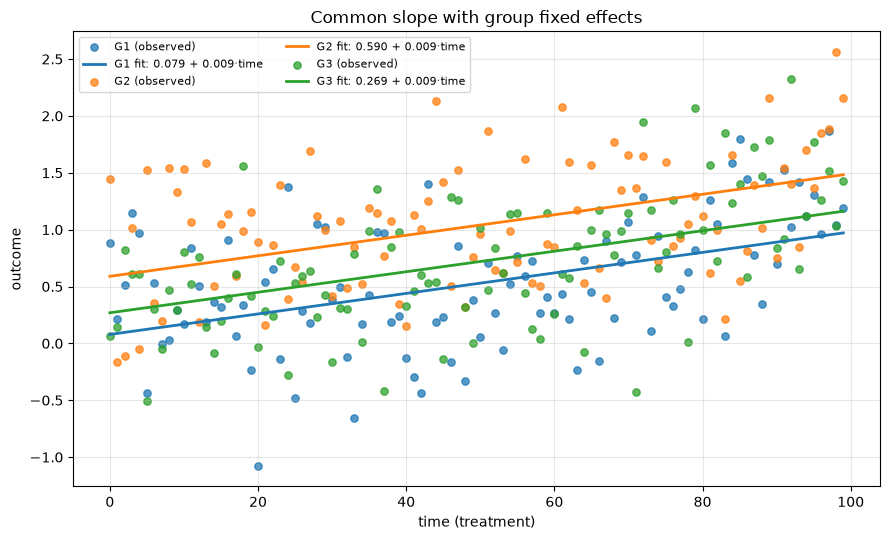

In [11]:
alpha = dict(zip(GROUPS, b[:len(GROUPS)]))
beta = b[-1]

fig, ax = plt.subplots(figsize=(9, 5.5))
grid = np.linspace(long["time"].min(), long["time"].max(), 100)

for g, color in zip(GROUPS, plt.rcParams["axes.prop_cycle"].by_key()["color"]):
    sub = long[long["group"] == g]
    ax.scatter(sub["time"], sub["y"], s=28, alpha=0.75, color=color, label=f"{g} (observed)")
    ax.plot(grid, alpha[g] + beta * grid, color=color, lw=2,
            label=f"{g} fit: {alpha[g]:.3f} + {beta:.3f}·time")

ax.set_xlabel("time (treatment)")
ax.set_ylabel("outcome")
ax.set_title("Common slope with group fixed effects")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

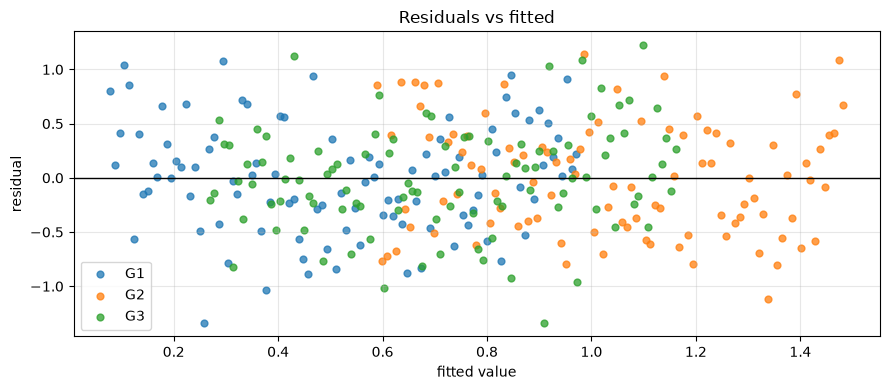

mean residual by group (should be ~0):
group
G1    0.000000
G2   -0.000000
G3   -0.000000
Name: resid, dtype: float64


In [12]:
# Residual check: fixed effects should leave no group-level mean residual.
long["fitted"] = X @ b
long["resid"] = long["y"] - long["fitted"]

fig, ax = plt.subplots(figsize=(9, 4))
for g in GROUPS:
    sub = long[long["group"] == g]
    ax.scatter(sub["fitted"], sub["resid"], s=24, alpha=0.75, label=g)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("fitted value")
ax.set_ylabel("residual")
ax.set_title("Residuals vs fitted")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("mean residual by group (should be ~0):")
print(long.groupby("group")["resid"].mean())

## 9. Answer

In [13]:
print("Estimated model:  y[g,t] = alpha[g] + beta * time + e[g,t]\n")
print(f"Common time coefficient (beta): {beta:.6f}"
      f"   (se {se[-1]:.6f}, t {t_stat[-1]:.3f}, p {p_val[-1]:.3g})\n")
print("Group fixed effects:")
for i, g in enumerate(GROUPS):
    print(f"  alpha[{g}] = {b[i]:10.6f}   (se {se[i]:.6f}, t {t_stat[i]:.3f}, p {p_val[i]:.3g})")

base = GROUPS[0]
print(f"\nDifferences relative to {base}:")
for g in GROUPS[1:]:
    print(f"  alpha[{g}] - alpha[{base}] = {alpha[g] - alpha[base]:.6f}")

Estimated model:  y[g,t] = alpha[g] + beta * time + e[g,t]

Common time coefficient (beta): 0.009017   (se 0.001004, t 8.982, p 3.19e-17)

Group fixed effects:
  alpha[G1] =   0.078552   (se 0.070633, t 1.112, p 0.267)
  alpha[G2] =   0.589654   (se 0.070633, t 8.348, p 2.69e-15)
  alpha[G3] =   0.269032   (se 0.070633, t 3.809, p 0.00017)

Differences relative to G1:
  alpha[G2] - alpha[G1] = 0.511102
  alpha[G3] - alpha[G1] = 0.190480
